# SQuAD RAG Metrics Comparison

Compares RAG evaluation metrics across all 4 chunking strategies and 2 retrieval modes.

**Strategies:**
- `baseline_258_tok` — fixed 258-token windows
- `most_recent_low_acc_258t_w128_wtd` — discourse-aware, window=128, weighted
- `most_recent_258t_w254` — discourse-aware, window=254, unweighted
- `nonlinear_258t_w254` — nonlinear discourse, window=254

**Retrieval modes:** `filtered` (per-article) vs `global` (full corpus)

**Metrics:** exact match, BERT CLS score, null answer rate

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.titlesize': 14,
})

METRICS_DIR = Path('squad_testing/metrics')

STRATEGIES = [
    'baseline_258_tok',
    'most_recent_low_acc_258t_w128_wtd',
    'most_recent_258t_w254',
    'nonlinear_258t_w254',
]
RETRIEVALS = ['filtered', 'global']

STRATEGY_SHORT = {
    'baseline_258_tok':                  'baseline',
    'most_recent_low_acc_258t_w128_wtd': 'mr_low_acc',
    'most_recent_258t_w254':             'mr_w254',
    'nonlinear_258t_w254':               'nonlinear',
}
COLORS = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

## Load Data

In [2]:
# --- Aggregate ---
agg_rows = []
for f in sorted(METRICS_DIR.glob('aggregate_*.json')):
    d = json.loads(f.read_text())
    d['null_rate'] = d['n_null_answers'] / d['n_questions']
    d['short'] = STRATEGY_SHORT[d['strategy']]
    agg_rows.append(d)
agg_df = pd.DataFrame(agg_rows)

# --- Per-question ---
pq_rows = []
for strategy in STRATEGIES:
    for retrieval in RETRIEVALS:
        path = METRICS_DIR / f'per_question_{strategy}_{retrieval}.json'
        if not path.exists():
            continue
        for rec in json.loads(path.read_text()):
            rec['strategy']  = strategy
            rec['retrieval'] = retrieval
            rec['short']     = STRATEGY_SHORT[strategy]
            rec['is_null']   = rec['generated_answer'] is None
            pq_rows.append(rec)
pq_df = pd.DataFrame(pq_rows)

print(f'Per-question rows: {len(pq_df)}')
print(f'Strategies × retrievals: {pq_df.groupby(["strategy","retrieval"]).size().to_dict()}')

Per-question rows: 8000
Strategies × retrievals: {('baseline_258_tok', 'filtered'): 1000, ('baseline_258_tok', 'global'): 1000, ('most_recent_258t_w254', 'filtered'): 1000, ('most_recent_258t_w254', 'global'): 1000, ('most_recent_low_acc_258t_w128_wtd', 'filtered'): 1000, ('most_recent_low_acc_258t_w128_wtd', 'global'): 1000, ('nonlinear_258t_w254', 'filtered'): 1000, ('nonlinear_258t_w254', 'global'): 1000}


## Aggregate Summary Table

All strategies and retrieval modes side by side.

In [3]:
table = agg_df.pivot_table(
    index='short',
    columns='retrieval',
    values=['mean_exact_match', 'mean_bert_cls', 'null_rate'],
)
table.index.name = 'strategy'
display(table.round(4))

mean_bert_cls        mean_exact_match        null_rate       
retrieval       filtered global         filtered global  filtered global
strategy                                                                
baseline          0.6320 0.5505           0.2950 0.2540    0.2960 0.3850
mr_low_acc        0.6337 0.5518           0.3040 0.2620    0.2960 0.3830
mr_w254           0.6045 0.5100           0.2930 0.2460    0.3290 0.4320
nonlinear         0.6169 0.5085           0.3080 0.2370    0.3170 0.4320

## Bar Charts — Core Metrics by Strategy

Filtered and global shown side by side per strategy.

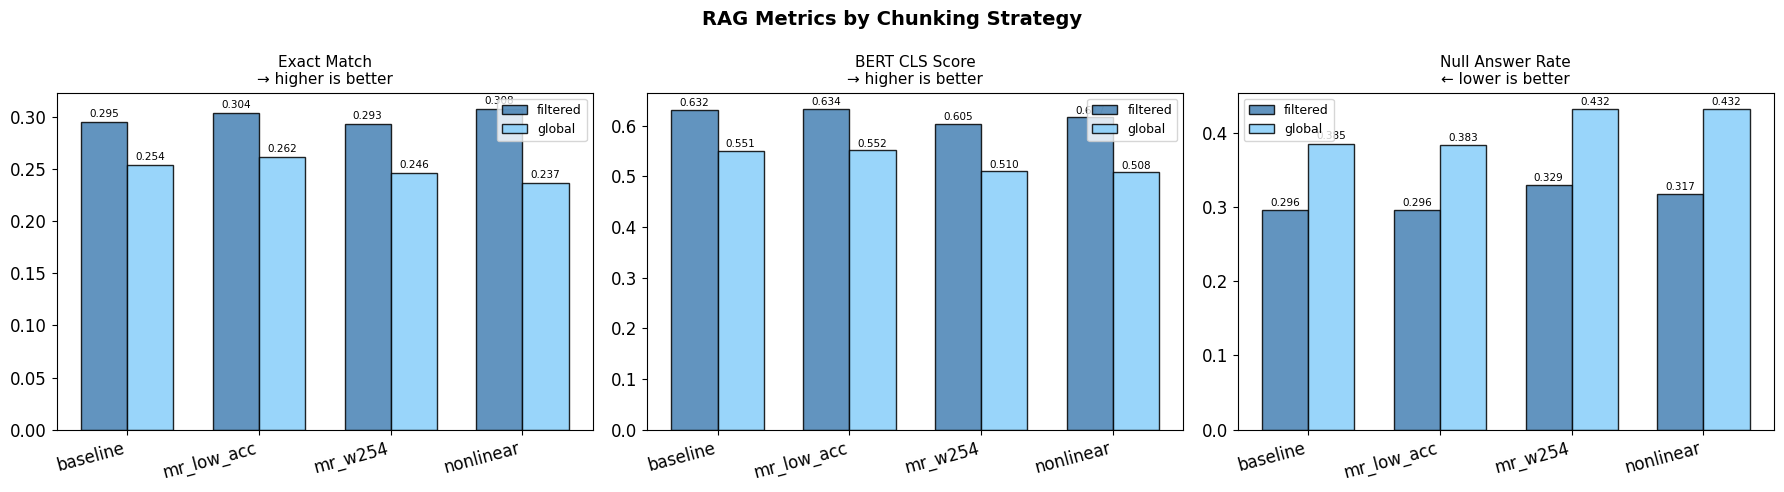

In [4]:
metrics_info = [
    ('mean_exact_match', 'Exact Match',      '→ higher is better'),
    ('mean_bert_cls',    'BERT CLS Score',   '→ higher is better'),
    ('null_rate',        'Null Answer Rate', '← lower is better'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RAG Metrics by Chunking Strategy', fontweight='bold')

x = np.arange(len(STRATEGIES))
width = 0.35
labels = [STRATEGY_SHORT[s] for s in STRATEGIES]

for ax, (metric, title, note) in zip(axes, metrics_info):
    filt_vals = [agg_df[(agg_df.strategy == s) & (agg_df.retrieval == 'filtered')][metric].values[0] for s in STRATEGIES]
    glob_vals = [agg_df[(agg_df.strategy == s) & (agg_df.retrieval == 'global')][metric].values[0]   for s in STRATEGIES]

    b1 = ax.bar(x - width/2, filt_vals, width, label='filtered', color='steelblue',   edgecolor='black', alpha=0.85)
    b2 = ax.bar(x + width/2, glob_vals, width, label='global',   color='lightskyblue', edgecolor='black', alpha=0.85)

    ax.set_title(f'{title}\n{note}', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.legend(fontsize=9)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

## Filtered vs Global — Retrieval Mode Impact

How much does switching from filtered to global retrieval hurt each strategy? A larger drop means the strategy is more sensitive to retrieval noise.

Δ = global − filtered  (negative = global is worse)


,em_delta,bert_delta,null_rate_delta
strategy,,,
baseline,-0.0410,-0.0815,0.0890
mr_low_acc,-0.0420,-0.0819,0.0870
mr_w254,-0.0470,-0.0946,0.1030
nonlinear,-0.0710,-0.1084,0.1150


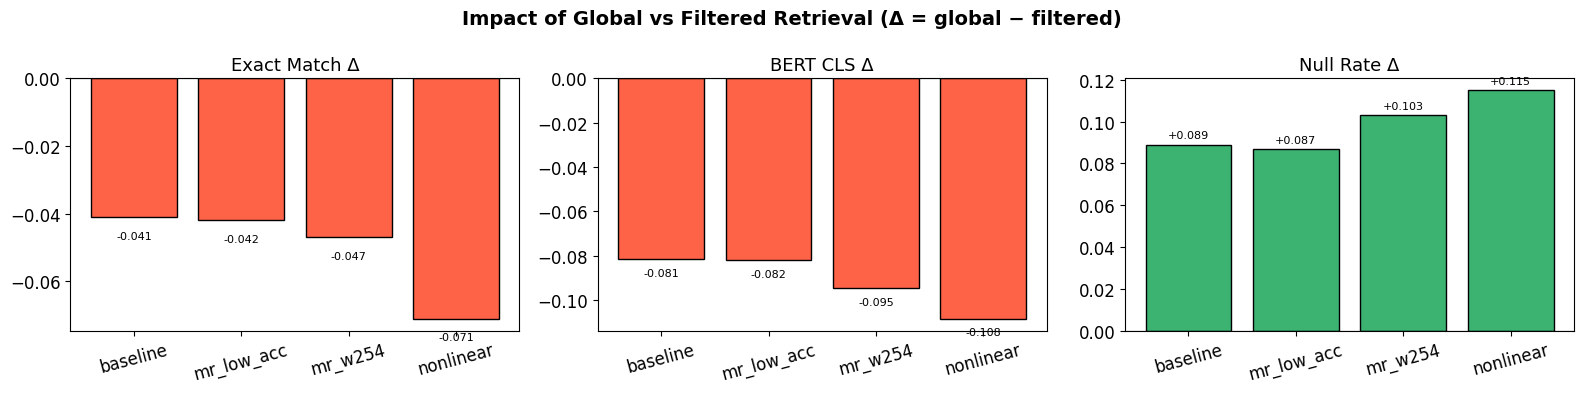

In [5]:
deltas = []
for strategy in STRATEGIES:
    f = agg_df[(agg_df.strategy == strategy) & (agg_df.retrieval == 'filtered')].iloc[0]
    g = agg_df[(agg_df.strategy == strategy) & (agg_df.retrieval == 'global')].iloc[0]
    deltas.append({
        'strategy':         STRATEGY_SHORT[strategy],
        'em_delta':         g['mean_exact_match'] - f['mean_exact_match'],
        'bert_delta':       g['mean_bert_cls']    - f['mean_bert_cls'],
        'null_rate_delta':  g['null_rate']         - f['null_rate'],
    })
delta_df = pd.DataFrame(deltas).set_index('strategy')

print('Δ = global − filtered  (negative = global is worse)')
display(delta_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Impact of Global vs Filtered Retrieval (Δ = global − filtered)', fontweight='bold')

delta_metrics = [('em_delta', 'Exact Match Δ'), ('bert_delta', 'BERT CLS Δ'), ('null_rate_delta', 'Null Rate Δ')]
for ax, (col, label) in zip(axes, delta_metrics):
    vals = delta_df[col]
    colors = ['tomato' if v < 0 else 'mediumseagreen' for v in vals]
    ax.bar(vals.index, vals, color=colors, edgecolor='black')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=15)
    for i, (idx, v) in enumerate(vals.items()):
        ax.text(i, v + (0.002 if v >= 0 else -0.004), f'{v:+.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

## Score Distributions — Non-Null Answers

Box plots of BERT CLS score across all answered questions (nulls excluded). Shows whether strategies differ in the *quality* of answers they do produce, separate from how often they abstain.

/var/folders/rq/m3kptmqx06q20dcm0n9s2kjm0000gp/T/ipykernel_33799/2337587342.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels, medianprops=dict(color='black', linewidth=2))
/var/folders/rq/m3kptmqx06q20dcm0n9s2kjm0000gp/T/ipykernel_33799/2337587342.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels, medianprops=dict(color='black', linewidth=2))


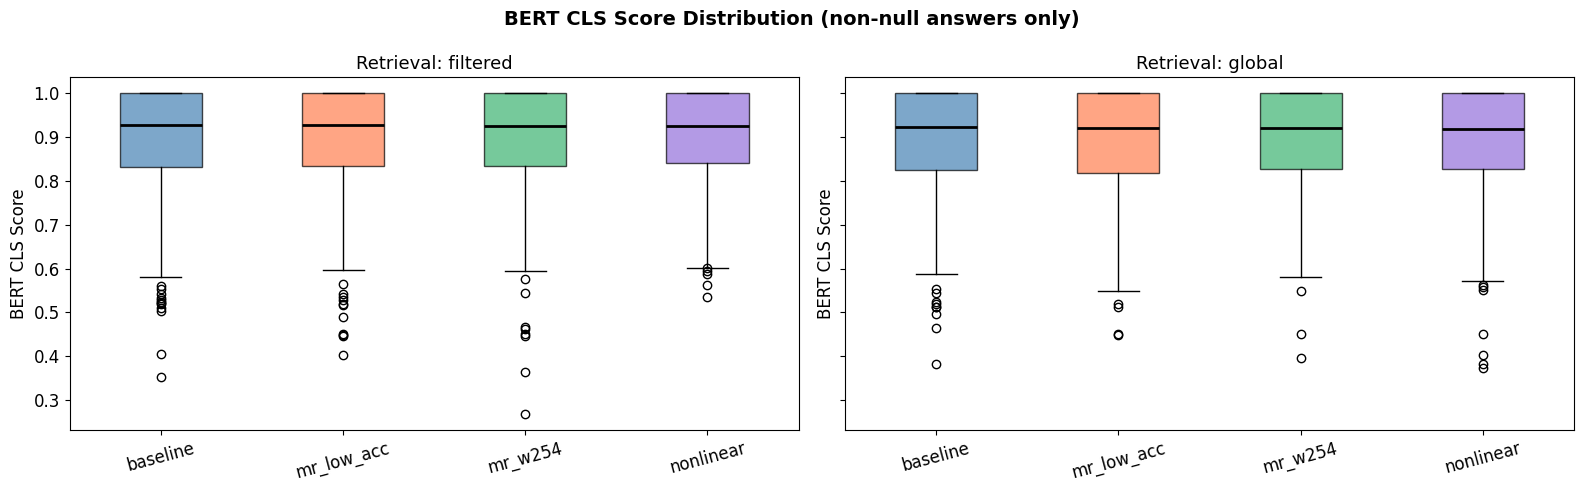

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle('BERT CLS Score Distribution (non-null answers only)', fontweight='bold')

for ax, retrieval in zip(axes, RETRIEVALS):
    sub = pq_df[(pq_df.retrieval == retrieval) & (~pq_df.is_null)]
    data   = [sub[sub.strategy == s]['bert_cls_score'].values for s in STRATEGIES]
    labels = [STRATEGY_SHORT[s] for s in STRATEGIES]

    bp = ax.boxplot(data, patch_artist=True, labels=labels, medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(f'Retrieval: {retrieval}')
    ax.set_ylabel('BERT CLS Score')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Null Answer Analysis

Are nulls concentrated in specific articles, or spread evenly? Top articles by null count (across all strategies, filtered retrieval).

In [7]:
null_sub = pq_df[pq_df.retrieval == 'filtered']

null_by_article = (
    null_sub.groupby('title')['is_null']
    .agg(null_count='sum', total='count')
    .assign(null_rate=lambda d: d.null_count / d.total)
    .sort_values('null_count', ascending=False)
    .head(20)
)
print('Top 20 articles by null answer count (filtered, all strategies combined):')
display(null_by_article)

# Null rate per strategy × retrieval
null_by_strat = (
    pq_df.groupby(['short', 'retrieval'])['is_null']
    .mean()
    .unstack()
    .round(4)
)
print('\nNull rate by strategy × retrieval:')
display(null_by_strat)

Top 20 articles by null answer count (filtered, all strategies combined):


,null_count,total,null_rate
title,,,
American_Idol,21,76,0.2763
Sino-Tibetan_relations_during_the_Ming_dynasty,20,20,1.0000
Financial_crisis_of_2007%E2%80%9308,20,20,1.0000
Gramophone_record,20,20,1.0000
Muslim_world,16,16,1.0000
Valencia,16,20,0.8000
Macintosh,16,16,1.0000
"St._John%27s,_Newfoundland_and_Labrador",16,16,1.0000
Jehovah%27s_Witnesses,16,16,1.0000



Null rate by strategy × retrieval:


retrieval,filtered,global
short,,
baseline,0.2960,0.3850
mr_low_acc,0.2960,0.3830
mr_w254,0.3290,0.4320
nonlinear,0.3170,0.4320


## Strategy Disagreement

Questions where strategies disagree on exact match (some get it right, others don't). Filtered retrieval only.

A high disagreement count on a question means the chunking strategy genuinely affects retrievability of the answer.

In [8]:
filt = pq_df[pq_df.retrieval == 'filtered'][['id', 'question', 'title', 'strategy', 'exact_match', 'bert_cls_score']]

em_pivot = filt.pivot_table(index=['id', 'question', 'title'], columns='strategy', values='exact_match')
em_pivot.columns = [STRATEGY_SHORT[c] for c in em_pivot.columns]
em_pivot['n_correct'] = em_pivot.sum(axis=1).astype(int)

# Questions where strategies disagree (at least one right, at least one wrong)
disagree = em_pivot[(em_pivot['n_correct'] > 0) & (em_pivot['n_correct'] < len(STRATEGIES))]
print(f'Questions with strategy disagreement: {len(disagree)} / {len(em_pivot)}')

print('\nDisagreement breakdown by n_correct:')
display(disagree['n_correct'].value_counts().sort_index().rename('count').to_frame())

print('\nSample questions where exactly 1 strategy gets it right:')
sample = disagree[disagree['n_correct'] == 1].head(8).reset_index()[['question', 'title'] + list(STRATEGY_SHORT.values())]
display(sample)

Questions with strategy disagreement: 157 / 1000

Disagreement breakdown by n_correct:


,count
n_correct,
1,50
2,43
3,64



Sample questions where exactly 1 strategy gets it right:


,question,title,baseline,mr_low_acc,mr_w254,nonlinear
0,Under which brand was Twilight Princess for th...,The_Legend_of_Zelda:_Twilight_Princess,0.0000,1.0000,0.0000,0.0000
1,Where did he end up living when he was 21?,Frédéric_Chopin,0.0000,0.0000,1.0000,0.0000
2,What plan of 1811 spread a grid of streets acr...,New_York_City,1.0000,0.0000,0.0000,0.0000
3,Chopin had three years of lessons with whom?,Frédéric_Chopin,0.0000,1.0000,0.0000,0.0000
4,Which contestant was surprisingly eliminated d...,American_Idol,0.0000,0.0000,1.0000,0.0000
5,How far did Jessica Sanchez make it on America...,American_Idol,1.0000,0.0000,0.0000,0.0000
6,What did foreign nations offer China because o...,2008_Sichuan_earthquake,0.0000,0.0000,1.0000,0.0000
7,When did season four premiere?,American_Idol,0.0000,1.0000,0.0000,0.0000


## Exact Match vs BERT CLS Score

For non-null answers, how aligned are EM and BERT score? High BERT + low EM means the model is producing semantically close but not exact answers.

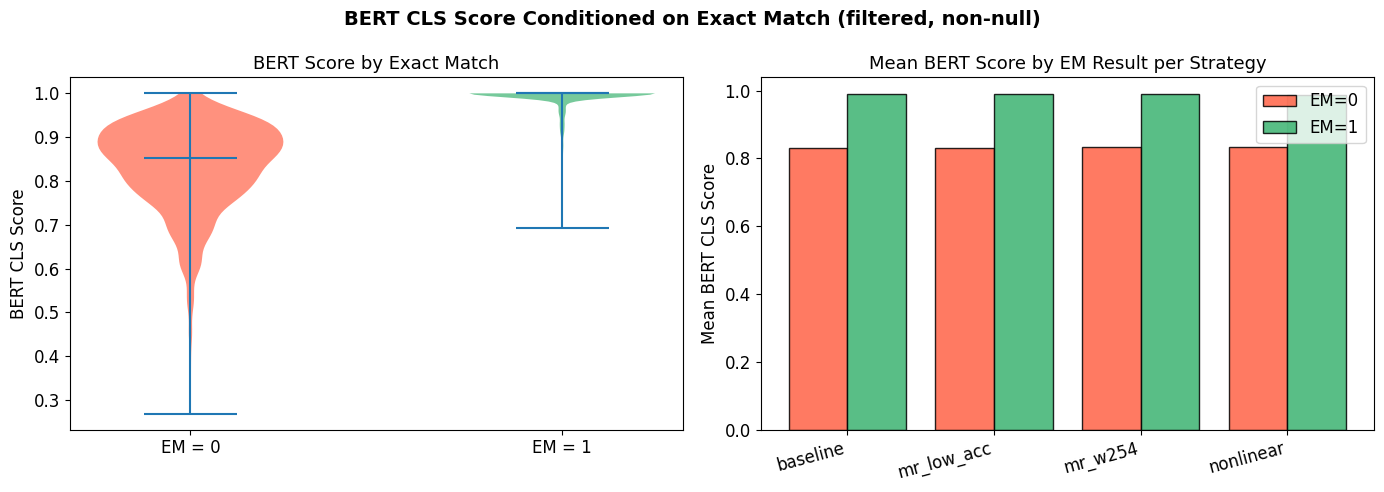

Near misses (EM=0, BERT≥0.8): 1072 (38.8% of non-null answered)


In [9]:
non_null = pq_df[(~pq_df.is_null) & (pq_df.retrieval == 'filtered')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT CLS Score Conditioned on Exact Match (filtered, non-null)', fontweight='bold')

# Violin: BERT score split by EM=0 vs EM=1
ax = axes[0]
em0 = non_null[non_null.exact_match == 0]['bert_cls_score']
em1 = non_null[non_null.exact_match == 1]['bert_cls_score']
vp = ax.violinplot([em0, em1], positions=[0, 1], showmedians=True)
for body, color in zip(vp['bodies'], ['tomato', 'mediumseagreen']):
    body.set_facecolor(color)
    body.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['EM = 0', 'EM = 1'])
ax.set_ylabel('BERT CLS Score')
ax.set_title('BERT Score by Exact Match')

# Mean BERT score for EM=0 vs EM=1, per strategy
ax = axes[1]
means = non_null.groupby(['short', 'exact_match'])['bert_cls_score'].mean().unstack()
means.columns = ['EM=0', 'EM=1']
x = np.arange(len(means))
ax.bar(x - 0.2, means['EM=0'], 0.4, label='EM=0', color='tomato',        edgecolor='black', alpha=0.85)
ax.bar(x + 0.2, means['EM=1'], 0.4, label='EM=1', color='mediumseagreen', edgecolor='black', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(means.index, rotation=15, ha='right')
ax.set_ylabel('Mean BERT CLS Score')
ax.set_title('Mean BERT Score by EM Result per Strategy')
ax.legend()

plt.tight_layout()
plt.show()

# How many non-null EM=0 answers still score above 0.8 BERT? (near misses)
near_misses = non_null[(non_null.exact_match == 0) & (non_null.bert_cls_score >= 0.8)]
print(f'Near misses (EM=0, BERT≥0.8): {len(near_misses)} ({100*len(near_misses)/len(non_null):.1f}% of non-null answered)')

## Per-Article Performance Heatmap

Mean exact match per article per strategy (filtered). Shows which articles are consistently hard or easy, and which benefit from a particular strategy.


Hardest 20 articles (lowest mean EM)


short,baseline,mr_low_acc,mr_w254,nonlinear,mean_across
title,,,,,
Plymouth,0.0000,0.0000,0.0000,0.0000,0.0000
Neptune,0.0000,0.0000,0.0000,0.0000,0.0000
Myanmar,0.0000,0.0000,0.0000,0.0000,0.0000
Estonian_language,0.0000,0.0000,0.0000,0.0000,0.0000
Eton_College,0.0000,0.0000,0.0000,0.0000,0.0000
European_Central_Bank,0.0000,0.0000,0.0000,0.0000,0.0000
Muslim_world,0.0000,0.0000,0.0000,0.0000,0.0000
Energy,0.0000,0.0000,0.0000,0.0000,0.0000
Multiracial_American,0.0000,0.0000,0.0000,0.0000,0.0000



Easiest 20 articles (highest mean EM)


short,baseline,mr_low_acc,mr_w254,nonlinear,mean_across
title,,,,,
Elizabeth_II,1.0000,1.0000,1.0000,1.0000,1.0000
National_Archives_and_Records_Administration,1.0000,1.0000,1.0000,1.0000,1.0000
Exhibition_game,1.0000,1.0000,1.0000,1.0000,1.0000
Chinese_characters,1.0000,1.0000,1.0000,1.0000,1.0000
Film_speed,1.0000,1.0000,1.0000,1.0000,1.0000
Software_testing,1.0000,1.0000,1.0000,1.0000,1.0000
Solar_energy,1.0000,1.0000,1.0000,1.0000,1.0000
Hard_rock,1.0000,1.0000,1.0000,1.0000,1.0000
Dialect,1.0000,1.0000,1.0000,1.0000,1.0000


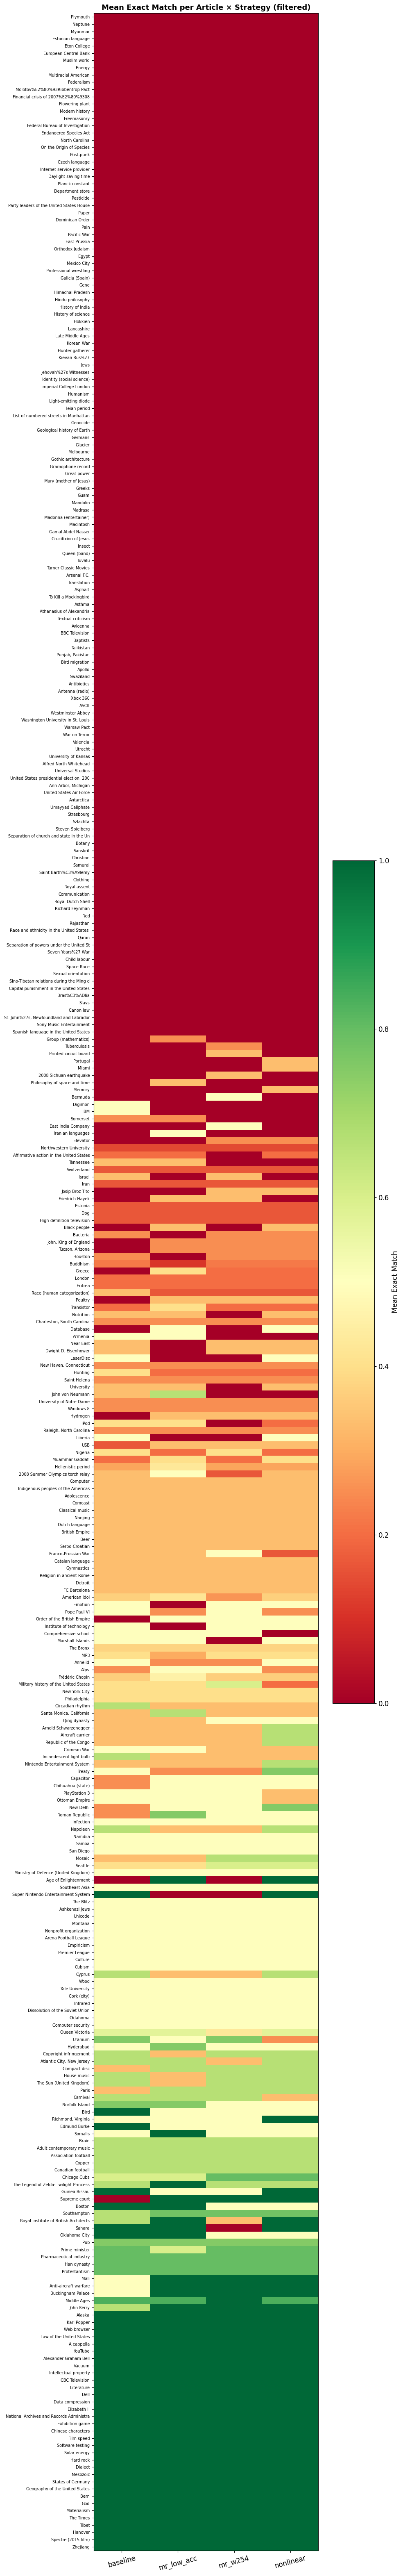

In [10]:
filt_df = pq_df[pq_df.retrieval == 'filtered']

article_em = filt_df.pivot_table(
    index='title', columns='short', values='exact_match', aggfunc='mean'
)
article_em['mean_across'] = article_em.mean(axis=1)
article_em = article_em.sort_values('mean_across')

# Show bottom 20 (hardest) and top 20 (easiest) articles
for label, subset in [('Hardest 20 articles (lowest mean EM)', article_em.head(20)),
                      ('Easiest 20 articles (highest mean EM)', article_em.tail(20))]:
    print(f'\n{label}')
    display(subset.round(3))

# Heatmap of all articles
heatmap_data = article_em.drop(columns='mean_across')
fig, ax = plt.subplots(figsize=(10, max(8, len(heatmap_data) * 0.18)))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=15)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([t.replace('_', ' ')[:40] for t in heatmap_data.index], fontsize=7)
ax.set_title('Mean Exact Match per Article × Strategy (filtered)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean Exact Match')
plt.tight_layout()
plt.show()

## Failure Analysis\n\nLoads raw `.jsonl` output files (which include `retrieved_chunk_indices`) and the original chunk files to show exactly what was retrieved and what the model said for the worst-performing questions.\n\nTwo failure modes:\n- **Confidently wrong** — all 4 strategies returned a non-null answer with EM=0, sorted by lowest mean BERT (retrieved context existed but the model still got it wrong)\n- **Universally abstained** — all 4 strategies returned null under filtered retrieval (nothing useful was retrieved for any strategy)

In [ ]:
OUTPUT_DIR = Path('squad_testing/output')
CHUNKS_BASE = Path('squad_testing/chunks')

CHUNK_DISPLAY_LEN = 350  # characters to show per chunk
TOP_CHUNKS = 2           # unique retrieved chunks to show per strategy
N_EXAMPLES = 10          # worst examples to display


def load_chunks_for_title(strategy: str, title: str) -> list[str]:
    """Load chunk list for a given strategy and title (title uses underscores as in jsonl)."""
    if strategy == 'baseline_258_tok':
        path = CHUNKS_BASE / strategy / title.replace('_', ' ') / 'chunks_output.json'
    else:
        path = CHUNKS_BASE / strategy / f'{title}.json'
    if not path.exists():
        return []
    return json.loads(path.read_text())['chunks']


def load_raw_jsonl(strategy: str, retrieval: str) -> dict[str, dict]:
    """Load a raw evaluated jsonl and return a dict keyed by question id."""
    path = OUTPUT_DIR / f'evaluated_squad_{strategy}_{retrieval}.jsonl'
    records = {}
    for line in path.read_text().strip().splitlines():
        r = json.loads(line)
        records[r['id']] = r
    return records


# Load all 8 raw jsonl files into a nested dict: raw[strategy][retrieval] -> {id: record}
raw = {s: {r: load_raw_jsonl(s, r) for r in RETRIEVALS} for s in STRATEGIES}
print('Raw jsonl loaded:', {s: {r: len(raw[s][r]) for r in RETRIEVALS} for s in STRATEGIES})

In [ ]:
def get_retrieved_chunks(strategy: str, retrieval: str, qid: str, title: str) -> list[str]:
    """Return the unique retrieved chunk texts for this question, in retrieval order."""
    rec = raw[strategy][retrieval].get(qid, {})
    indices = rec.get('retrieved_chunk_indices', [])
    all_chunks = load_chunks_for_title(strategy, title)
    if not all_chunks:
        return []
    seen = set()
    unique_chunks = []
    for idx in indices:
        if idx not in seen and idx < len(all_chunks):
            seen.add(idx)
            unique_chunks.append(all_chunks[idx])
    return unique_chunks


def display_example(qid: str, question: str, title: str, gold: list[str], retrieval: str):
    """Pretty-print a single failure example with per-strategy answers and retrieved chunks."""
    sep = '─' * 80
    print(sep)
    print(f'  ID    : {qid}')
    print(f'  TITLE : {title.replace("_", " ")}')
    print(f'  Q     : {question}')
    print(f'  GOLD  : {" | ".join(gold)}')
    print()
    for strategy in STRATEGIES:
        short = STRATEGY_SHORT[strategy]
        pq_rec = pq_df[(pq_df.id == qid) & (pq_df.strategy == strategy) & (pq_df.retrieval == retrieval)]
        if pq_rec.empty:
            continue
        row = pq_rec.iloc[0]
        gen = row['generated_answer'] if row['generated_answer'] is not None else '(null)'
        bert = row['bert_cls_score']
        em   = int(row['exact_match'])
        print(f'  [{short:12s}]  EM={em}  BERT={bert:.3f}  →  {gen}')

        chunks = get_retrieved_chunks(strategy, retrieval, qid, title)
        for i, chunk in enumerate(chunks[:TOP_CHUNKS]):
            preview = chunk[:CHUNK_DISPLAY_LEN].replace('\n', ' ')
            ellipsis = '…' if len(chunk) > CHUNK_DISPLAY_LEN else ''
            print(f'    chunk {i+1}: {preview}{ellipsis}')
        print()
    print()

### Confidently Wrong\n\nQuestions where all 4 strategies returned a non-null answer under filtered retrieval but every strategy got EM=0. Sorted by mean BERT score ascending — the very bottom are cases where the model hallucinated something completely unrelated.

In [ ]:
RETRIEVAL = 'filtered'

filt_pq = pq_df[pq_df.retrieval == RETRIEVAL]

# Per question: count non-null strategies and mean BERT
q_stats = (
    filt_pq.groupby(['id', 'question', 'title'])
    .agg(
        n_nonnull=('is_null', lambda x: (~x).sum()),
        n_em_zero=('exact_match', lambda x: (x == 0).sum()),
        mean_bert=('bert_cls_score', 'mean'),
        gold=('gold_answers', 'first'),
    )
    .reset_index()
)

# All 4 strategies non-null, all 4 EM=0
confidently_wrong = (
    q_stats[(q_stats.n_nonnull == len(STRATEGIES)) & (q_stats.n_em_zero == len(STRATEGIES))]
    .sort_values('mean_bert')
)
print(f'Confidently wrong (all non-null, all EM=0): {len(confidently_wrong)} questions')
print(f'Mean BERT range: {confidently_wrong.mean_bert.min():.3f} – {confidently_wrong.mean_bert.max():.3f}\n')

for _, row in confidently_wrong.head(N_EXAMPLES).iterrows():
    display_example(row['id'], row['question'], row['title'], row['gold'], RETRIEVAL)

### Universally Abstained\n\nQuestions where all 4 strategies returned null under filtered retrieval — the retriever never surfaced a relevant chunk regardless of chunking strategy. These are questions the whole system consistently fails on at the retrieval step.

In [ ]:
universally_abstained = q_stats[q_stats.n_nonnull == 0].sort_values('title')

print(f'Universally abstained (all null, filtered): {len(universally_abstained)} questions')
print(f'Spread across {universally_abstained.title.nunique()} articles\n')

for _, row in universally_abstained.head(N_EXAMPLES).iterrows():
    sep = '─' * 80
    print(sep)
    print(f'  ID    : {row["id"]}')
    print(f'  TITLE : {row["title"].replace("_", " ")}')
    print(f'  Q     : {row["question"]}')
    print(f'  GOLD  : {" | ".join(row["gold"])}')
    print()
    # Show what was retrieved (even though the model returned null, chunks were still fetched)
    for strategy in STRATEGIES:
        short = STRATEGY_SHORT[strategy]
        chunks = get_retrieved_chunks(strategy, RETRIEVAL, row['id'], row['title'])
        print(f'  [{short:12s}]  → (null)')
        for i, chunk in enumerate(chunks[:TOP_CHUNKS]):
            preview = chunk[:CHUNK_DISPLAY_LEN].replace('\n', ' ')
            ellipsis = '…' if len(chunk) > CHUNK_DISPLAY_LEN else ''
            print(f'    chunk {i+1}: {preview}{ellipsis}')
        print()
    print()